In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# İşletim sistemiyle ilgili işlemler yapabilmek için 'os' kütüphanesini içe aktarıyoruz.
import os

# Veri setimizin bulunduğu ana klasörün yolunu bir değişkene atıyoruz.
# Çıkartma işlemi bu klasörün içine yapılacak.
data_dir = '/content/drive/MyDrive/Colab_Datasets/RpsDataset'

# Drive'a yüklediğiniz ZIP dosyasının tam yolunu belirtiyoruz.
# Eğer Kaggle'dan indirildiği gibi 'archive.zip' ise bu yolu değiştirmeyin.
# Farklı bir isim verdiyseniz, 'archive.zip' kısmını güncelleyin.
zip_path = os.path.join(data_dir, 'archive (1).zip')

# Colab'de terminal komutlarını çalıştırmak için '!' karakterini kullanıyoruz.
# !unzip komutu ile belirtilen ZIP dosyasını, '-d' parametresi ile belirttiğimiz
# hedef klasörün içine çıkartıyoruz.
# '-q' parametresi, 2000'den fazla dosyanın ismini tek tek ekrana yazdırmaması,
# yani "sessiz modda" çalışması için kullanılır. Bu, çıktının temiz kalmasını sağlar.
print(f"'{zip_path}' dosyasını '{data_dir}' klasörüne çıkartma işlemi başlatılıyor...")

!unzip -q "{zip_path}" -d "{data_dir}"

print("Çıkartma işlemi tamamlandı.")

'/content/drive/MyDrive/Colab_Datasets/RpsDataset/archive (1).zip' dosyasını '/content/drive/MyDrive/Colab_Datasets/RpsDataset' klasörüne çıkartma işlemi başlatılıyor...
Çıkartma işlemi tamamlandı.


In [ ]:
# Çıkartma işleminin başarılı olup olmadığını kontrol edelim.
# Klasör içeriğinde 'rock', 'paper', ve 'scissors' olmalı.
print(f"'{data_dir}' klasörünün güncel içeriği:")
print(os.listdir(data_dir))

'/content/drive/MyDrive/Colab_Datasets/RpsDataset' klasörünün güncel içeriği:
['README_rpc-cv-images.txt', 'archive (1).zip', 'paper', 'rock', 'scissors']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# TensorFlow'un versiyonunu yazdırarak kurulumun başarılı olduğunu teyit ediyoruz.
print("TensorFlow Sürümü:", tf.__version__)
# TensorFlow'un bir GPU cihazı bulup bulamadığını kontrol edelim.
print("Kullanılabilir GPU'lar:", tf.config.list_physical_devices('GPU'))

TensorFlow Sürümü: 2.19.0
Kullanılabilir GPU'lar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import shutil # Dosya ve klasör işlemleri için kullanılan güçlü bir kütüphane

# Faz 0'da tanımladığımız veri setimizin ana klasör yolu
# Lütfen bu yolun sizin için doğru olduğundan emin olun.
data_dir = '/content/drive/MyDrive/Colab_Datasets/RpsDataset'

# Silmek istediğimiz istenmeyen klasörün tam yolunu oluşturuyoruz.
unwanted_dir_path = os.path.join(data_dir, 'rps-cv-images')

print(f"Kontrol edilen yol: {unwanted_dir_path}")

# Eğer bu yolda bir klasör varsa, onu ve içindeki her şeyi sileceğiz.
# Bu kontrol, kodu tekrar tekrar çalıştırsanız bile hata vermesini engeller.
if os.path.exists(unwanted_dir_path):
    print("İstenmeyen klasör bulundu, siliniyor...")
    # shutil.rmtree, bir klasörü içindekilerle birlikte tamamen siler.
    shutil.rmtree(unwanted_dir_path)
    print("Klasör başarıyla silindi.")
else:
    print("İstenmeyen klasör zaten mevcut değil. Harika!")

# Temizlik sonrası ana klasörün içeriğini tekrar kontrol edelim.
print(f"\nKlasörün son içeriği: {os.listdir(data_dir)}")

Kontrol edilen yol: /content/drive/MyDrive/Colab_Datasets/RpsDataset/rps-cv-images
İstenmeyen klasör zaten mevcut değil. Harika!

Klasörün son içeriği: ['README_rpc-cv-images.txt', 'archive (1).zip', 'paper', 'rock', 'scissors']


Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.

--- Veri Yükleme Tamamlandı. Görsel Doğrulama Yapılıyor... ---



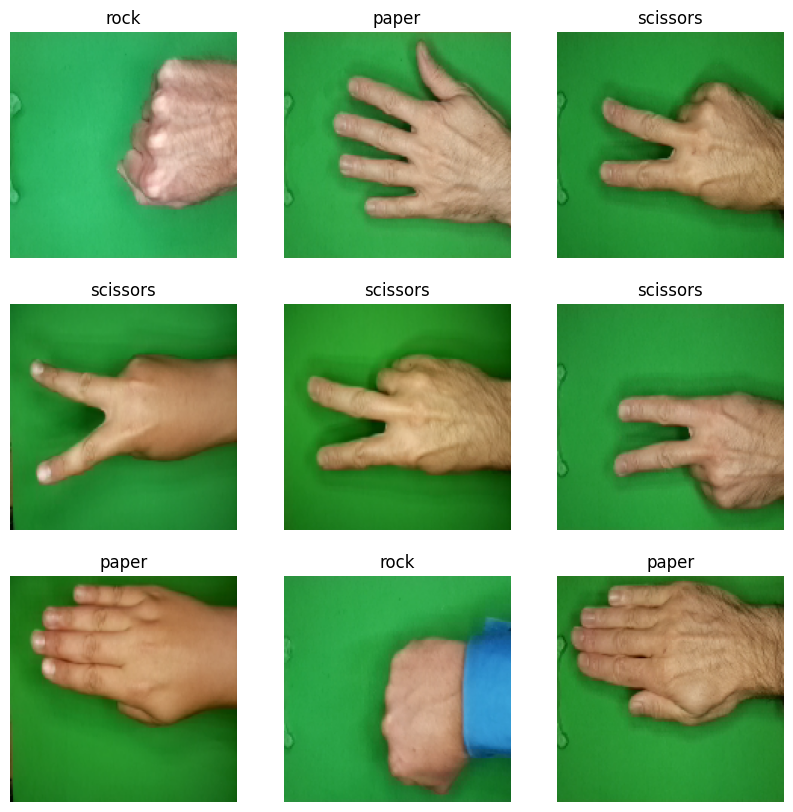

In [ ]:
# --- Gerekli Kütüphaneleri Yükleme ---
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- Parametreleri Tanımlama ---

# LÜTFEN DİKKAT: Bu yolun sizin Google Drive yapınızla aynı olduğundan emin olun.
# Faz 0'daki çıktıya göre yolunuz: '/content/drive/MyDrive/Colab_Datasets/RpsDataset'
data_dir = '/content/drive/MyDrive/Colab_Datasets/RpsDataset'

# Modelimize girecek tüm resimleri yeniden boyutlandıracağımız standart boyut.
IMG_SIZE = 150
# Verileri modele kaçarlı gruplar halinde besleyeceğimiz (batch size).
BATCH_SIZE = 32

# --- Veri Üreteci (Data Generator) Oluşturma ---

# Bu nesne, resimleri okuyup modele hazır hale getirecek olan yapılandırıcıdır.
datagen = ImageDataGenerator(
    rescale=1./255,         # Piksel değerlerini 0-255'ten 0-1 aralığına indirger.
    validation_split=0.2    # Veri setinin %20'sini doğrulama için ayırır.
)

# --- Eğitim ve Doğrulama Verilerini Akış Haline Getirme ---

# EĞİTİM VERİSİ ÜRETECİ: Klasördeki verilerin %80'ini alır.
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # Sınıflandırma türü (rock, paper, scissors -> 3 sınıf)
    subset='training'           # Bu üretecin "eğitim" alt kümesini kullanacağını belirtir.
)

# DOĞRULAMA VERİSİ ÜRETECİ: Klasördeki verilerin %20'sini alır.
validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'         # Bu üretecin "doğrulama" alt kümesini kullanacağını belirtir.
)

print("\n--- Veri Yükleme Tamamlandı. Görsel Doğrulama Yapılıyor... ---\n")

# --- Veriyi Görselleştirerek Doğrulama ---

# Eğitim üretecinden bir demet (batch) veri alalım.
images, labels = next(train_generator)

# Sınıf isimlerini alalım (['paper', 'rock', 'scissors'])
class_names = list(train_generator.class_indices.keys())

# 3x3'lük bir görsel alanı hazırlayalım.
plt.figure(figsize=(10, 10))

# İlk 9 resmi ve etiketlerini bu alana çizdirelim.
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Etiketi (örn: [0., 0., 1.]) sınıf ismine (örn: 'scissors') çeviriyoruz.
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

# Hazırlanan görseli ekranda gösterelim.
plt.show()

In [ ]:
# Gerekli TensorFlow ve Keras katmanlarını içe aktarıyoruz.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Modelimizi Sequential (sıralı) bir model olarak başlatıyoruz.
# Yani katmanları basitçe üst üste ekleyeceğiz.
model = Sequential([
    # 1. EVRİŞİM BLOĞU
    # ------------------
    # 32 filtre ile görüntüdeki temel özellikleri (kenarlar, köşeler) bulur.
    # input_shape, modele verilecek resmin boyutunu ve kanal sayısını (RGB=3) belirtir.
    # Bu sadece ilk katmanda gereklidir.
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Öğrenilen özellik haritasının boyutunu küçülterek en belirgin özellikleri korur.
    MaxPooling2D(2, 2),

    # 2. EVRİŞİM BLOĞU
    # ------------------
    # Filtre sayısını 64'e çıkararak daha karmaşık desenleri öğrenir.
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # 3. EVRİŞİM BLOĞU
    # ------------------
    # Filtre sayısını 128'e çıkararak daha da karmaşık, nesneye özgü özellikleri öğrenir.
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # KARAR VERME BLOĞU
    # ------------------
    # Evrişim katmanlarından gelen 2D özellik haritalarını tek boyutlu bir vektöre düzleştirir.
    Flatten(),
    # Modelin ezber yapmasını (overfitting) önlemek için nöronların %50'sini rastgele kapatır.
    # Bu, modelin genelleme yeteneğini artırır.
    Dropout(0.5),
    # 512 nörondan oluşan tam bağlantılı katman. Sınıflandırma için desenleri birleştirir.
    Dense(512, activation='relu'),
    # ÇIKIŞ KATMANI: 3 nörondan oluşur (rock, paper, scissors).
    # 'softmax' aktivasyonu, her sınıf için bir olasılık değeri üretir (toplamları 1.0 olur).
    Dense(3, activation='softmax')
])

# Modelimizin mimarisini, katmanlarını ve parametre sayısını özetleyen bir tablo yazdırır.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Keras'ın metrik modülünü ve F1Score'u içe aktarıyoruz.
from tensorflow.keras import metrics
from tensorflow.keras.metrics import F1Score

# F1-Score metriğini 'macro' ortalama ile başlatıyoruz.
# 'macro' ortalama, her sınıfın metriğini bağımsız olarak hesaplar ve
# ardından ağırlıklandırma yapmadan ortalamasını alır. Dengeli veri setleri için idealdir.
f1_macro = F1Score(average='macro', name='f1_score') # Adını 'f1_score' olarak belirledik

# Modelimizi eğitim için yapılandırıyoruz.
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    # Takip edeceğimiz metrikler listesine F1-Score'u da ekliyoruz.
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'), # İsimlerini belirlemek iyi bir alışkanlıktır
        metrics.Recall(name='recall'),
        f1_macro
    ]
)

# Derlemenin başarıyla tamamlandığını belirten bir mesaj yazdırıyoruz.
print("Model; accuracy, precision, recall ve f1_score metrikleriyle başarıyla derlendi.")

Model; accuracy, precision, recall ve f1_score metrikleriyle başarıyla derlendi.


In [ ]:
epochs = 20

# Orijinal Keras ilerleme çubuğunu ve metriklerini kullanmak için verbose=1 yeterlidir.
history = model.fit(
      train_generator,
      epochs=epochs,
      validation_data=validation_generator,
      # verbose=1, her epoch için ayrı bir ilerleme çubuğu ve metrikleri gösterir.
      verbose=1
)
print("\n--- Model Eğitimi Tamamlandı! ---")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 25s 312ms/step - accuracy: 0.5255 - f1_score: 0.5087 - loss: 1.0568 - precision: 0.6101 - recall: 0.2605 - val_accuracy: 0.8970 - val_f1_score: 0.8956 - val_loss: 0.2808 - val_precision: 0.9129 - val_recall: 0.8879
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.9166 - f1_score: 0.9163 - loss: 0.2344 - precision: 0.9272 - recall: 0.9085 - val_accuracy: 0.9405 - val_f1_score: 0.9397 - val_loss: 0.1641 - val_precision: 0.9512 - val_recall: 0.9359
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.9617 - f1_score: 0.9615 - loss: 0.1242 - precision: 0.9630 - recall: 0.9580 - val_accuracy: 0.9565 - val_f1_score: 0.9565 - val_loss: 0.1193 - val_precision: 0.9607 - val_recall: 0.9519
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - accuracy: 0.9677 - f1_score: 0.9676 - loss: 0.0850 - precision: 0.9711 - recall: 0.9668 - val_accuracy: 0.9634 - val_f1_score: 0.9632 - val_loss: 0.1196 - val_precision: 0.9677 - val_rec

dict_keys(['accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])


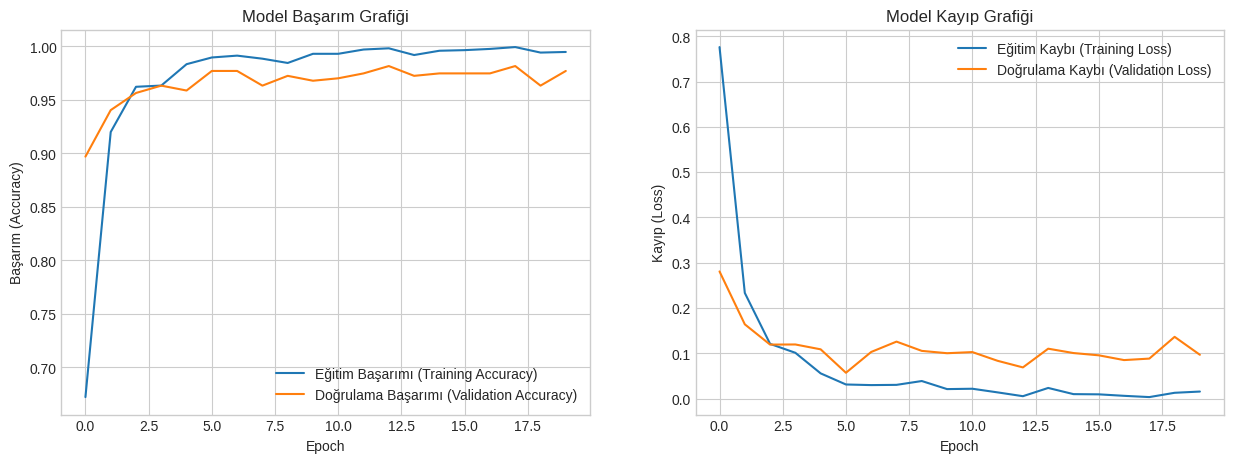

In [ ]:
# Eğitim sırasında kaydettiğimiz 'history' nesnesinin içeriğine bakalım.
# Her metriğin 20 epoch boyunca kaydedilmiş değerlerini içerir.
print(history.history.keys())

# --- GRAFİKLERİ ÇİZDİRME ---

# Grafiklerin daha okunaklı olması için bir stil belirleyelim.
plt.style.use('seaborn-v0_8-whitegrid')

# İki grafiği yan yana çizdirmek için bir figür ve 2 alt-grafik alanı oluşturuyoruz.
plt.figure(figsize=(15, 5))

# 1. Alt-grafik: Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarımı (Training Accuracy)')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarımı (Validation Accuracy)')
plt.title('Model Başarım Grafiği')
plt.ylabel('Başarım (Accuracy)')
plt.xlabel('Epoch')
plt.legend(loc='lower right') # Etiketlerin konumunu belirliyoruz.

# 2. Alt-grafik: Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Training Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Validation Loss)')
plt.title('Model Kayıp Grafiği')
plt.ylabel('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Grafikleri göster
plt.show()

In [ ]:
# --- Gerekli Modülleri Yükleme ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics
from tensorflow.keras.metrics import F1Score

# --- 1. Adım: EarlyStopping Callback'ini GÜNCELLENMİŞ Patience ile Hazırlama ---

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # SABIR DEĞERİNİ 3'TEN 5'E YÜKSELTTİK.
    restore_best_weights=True,
    verbose=1
)


# --- 2. Adım: Modeli Sıfırdan Yeniden Oluşturma ---
model_optimized_v2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

# --- 3. Adım: Modeli Yeniden Derleme ---
f1_macro = F1Score(average='macro', name='f1_score')
model_optimized_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', metrics.Precision(name='precision'), metrics.Recall(name='recall'), f1_macro]
)

print("--- Optimize Edilecek Model (v2) Kuruldu ve Derlendi ---")
print("--- EarlyStopping (patience=5) ile Eğitim Başlatılıyor... ---\n")

# --- 4. Adım: Modeli Güncellenmiş Callback ile Yeniden Eğitme ---
history_optimized_v2 = model_optimized_v2.fit(
      train_generator,
      epochs=20,
      validation_data=validation_generator,
      verbose=1,
      callbacks=[early_stopping]
)

print("\n--- Model Eğitimi (EarlyStopping patience=5 ile) Tamamlandı! ---")

--- Optimize Edilecek Model (v2) Kuruldu ve Derlendi ---
--- EarlyStopping (patience=5) ile Eğitim Başlatılıyor... ---

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.4744 - f1_score: 0.4675 - loss: 1.4570 - precision: 0.5146 - recall: 0.1779 - val_accuracy: 0.8696 - val_f1_score: 0.8695 - val_loss: 0.4540 - val_precision: 0.9059 - val_recall: 0.8375
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 196ms/step - accuracy: 0.8607 - f1_score: 0.8593 - loss: 0.4126 - precision: 0.8849 - recall: 0.8364 - val_accuracy: 0.9062 - val_f1_score: 0.9059 - val_loss: 0.2474 - val_precision: 0.9198 - val_recall: 0.8924
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.9203 - f1_score: 0.9197 - loss: 0.2254 - precision: 0.9296 - recall: 0.9106 - val_accuracy: 0.9428 - val_f1_score: 0.9425 - val_loss: 0.1594 - val_precision: 0.9470 - val_recall: 0.9405
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.9578 - f1_score: 0.9570 - loss: 0.1163 - precision: 0.

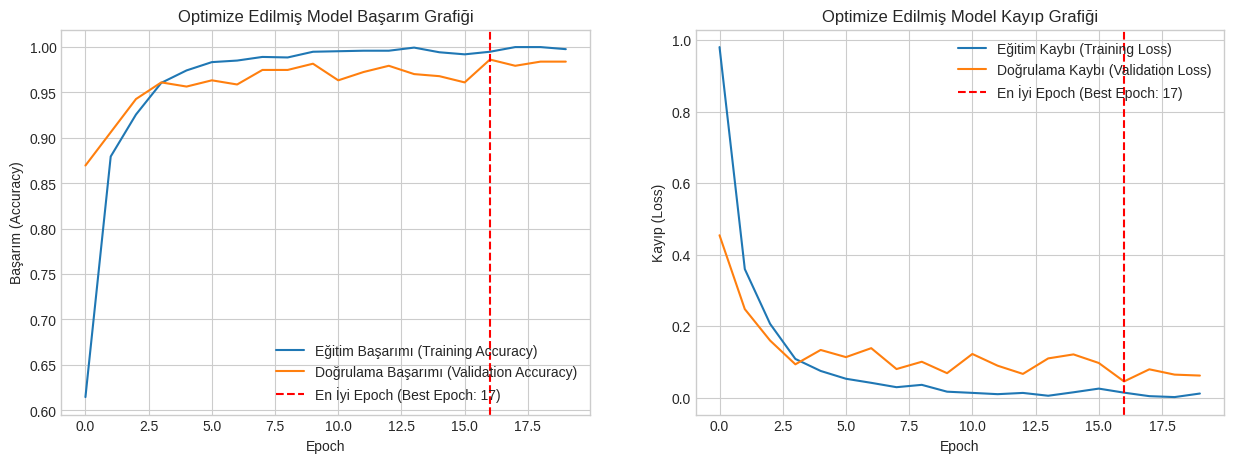

In [ ]:
# --- OPTİMİZE EDİLMİŞ SONUÇLARI GÖRSELLEŞTİRME ---

# Grafiklerin daha okunaklı olması için bir stil belirleyelim.
plt.style.use('seaborn-v0_8-whitegrid')

# İki grafiği yan yana çizdirmek için bir figür ve 2 alt-grafik alanı oluşturuyoruz.
plt.figure(figsize=(15, 5))

# 1. Alt-grafik: Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
# ÖNEMLİ: Bu sefer 'history_optimized_v2' değişkenini kullanıyoruz.
plt.plot(history_optimized_v2.history['accuracy'], label='Eğitim Başarımı (Training Accuracy)')
plt.plot(history_optimized_v2.history['val_accuracy'], label='Doğrulama Başarımı (Validation Accuracy)')
# En iyi epoch'u grafikte dikey bir çizgi ile işaretleyelim.
plt.axvline(x=16, color='r', linestyle='--', label='En İyi Epoch (Best Epoch: 17)') # index 0'dan başladığı için 16. index 17. epoch'tur
plt.title('Optimize Edilmiş Model Başarım Grafiği')
plt.ylabel('Başarım (Accuracy)')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# 2. Alt-grafik: Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
# ÖNEMLİ: Bu sefer 'history_optimized_v2' değişkenini kullanıyoruz.
plt.plot(history_optimized_v2.history['loss'], label='Eğitim Kaybı (Training Loss)')
plt.plot(history_optimized_v2.history['val_loss'], label='Doğrulama Kaybı (Validation Loss)')
# En iyi epoch'u grafikte dikey bir çizgi ile işaretleyelim.
plt.axvline(x=16, color='r', linestyle='--', label='En İyi Epoch (Best Epoch: 17)')
plt.title('Optimize Edilmiş Model Kayıp Grafiği')
plt.ylabel('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Grafikleri göster
plt.show()

In [ ]:
# En son eğittiğimiz ve EarlyStopping ile en iyi noktada duran modelimizi kaydediyoruz.
# Modelin adı 'model_optimized_v2' idi.
model_optimized_v2.save('rps_model.keras')

print("Model başarıyla 'rps_model.keras' adıyla kaydedildi.")

# Dosyanın Colab ortamında oluşturulduğunu teyit edelim.
# Çıktıda 'rps_model.keras' dosyasını görmelisiniz.
!ls

Model başarıyla 'rps_model.keras' adıyla kaydedildi.
drive  rps_model.keras	sample_data


In [ ]:
# --- Gerekli Modülleri Yükleme ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics
from tensorflow.keras.metrics import F1Score

# --- 1. Adım: Veri Artırma (Data Augmentation) ile Yeni Veri Üreteçleri ---

# EĞİTİM İÇİN VERİ ARTIRMA UYGULAYAN ÜRETEÇ
# Bu sefer, eğitim verilerini rastgele değiştirerek modelin genelleme yeteneğini artırıyoruz.
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # Resimleri +/- 20 derece döndürür
    width_shift_range=0.2,      # Yatayda %20'ye kadar kaydırır
    height_shift_range=0.2,     # Dikeyde %20'ye kadar kaydırır
    shear_range=0.2,            # Eğip büker
    zoom_range=0.2,             # %20'ye kadar zoom yapar
    horizontal_flip=True,       # Yatayda rastgele çevirir
    fill_mode='nearest',        # Oluşan boşlukları en yakın pikselle doldurur
    validation_split=0.2
)

# DOĞRULAMA İÇİN VERİ ARTIRMA UYGULAMIYORUZ!
# Sadece piksel ölçekleme yapıyoruz, çünkü modelin gerçek performasını
# orijinal, dokunulmamış verilerde görmek isteriz.
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


# Yeni Üreteçleri Oluşturma
train_generator_aug = train_datagen_augmented.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator_aug = validation_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# --- 2. Adım: Modeli Sıfırdan Yeniden Oluşturma ---
# (Mimari aynı, sadece adı farklı)
model_robust = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)), MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'), MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'), MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

# --- 3. Adım: Modeli Yeniden Derleme ve Eğitme ---
f1_macro = F1Score(average='macro', name='f1_score')
model_robust.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', metrics.Precision(name='precision'), metrics.Recall(name='recall'), f1_macro])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("--- Veri Artırma ile Dayanıklı Model Eğitimi Başlatılıyor... ---\n")

history_robust = model_robust.fit(
    train_generator_aug,
    epochs=30, # Veri artırma daha zorlu olduğu için biraz daha fazla epoch tanıyoruz.
    validation_data=validation_generator_aug,
    verbose=1,
    callbacks=[early_stopping]
)

print("\n--- Dayanıklı Model Eğitimi Tamamlandı! ---")

# --- 4. Adım: Son ve En Güçlü Modeli Kaydetme ---
model_robust.save('rps_model_robust.keras')
print("En dayanıklı model 'rps_model_robust.keras' adıyla kaydedildi.")

Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.
--- Veri Artırma ile Dayanıklı Model Eğitimi Başlatılıyor... ---



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 362s 6s/step - accuracy: 0.3448 - f1_score: 0.3260 - loss: 1.2067 - precision: 0.4000 - recall: 0.0653 - val_accuracy: 0.6430 - val_f1_score: 0.6324 - val_loss: 1.0396 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 25s 455ms/step - accuracy: 0.4923 - f1_score: 0.4830 - loss: 1.0152 - precision: 0.6105 - recall: 0.1463 - val_accuracy: 0.7483 - val_f1_score: 0.7417 - val_loss: 0.7643 - val_precision: 0.8839 - val_recall: 0.4531
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 25s 453ms/step - accuracy: 0.6142 - f1_score: 0.6127 - loss: 0.8422 - precision: 0.6924 - recall: 0.4815 - val_accuracy: 0.9222 - val_f1_score: 0.9194 - val_loss: 0.3811 - val_precision: 0.9463 - val_recall: 0.8879
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.7702 - f1_score: 0.7658 - loss: 0.6029 - precision: 0.8001 - recall: 0.7308 - val_accuracy: 0.9016 - val_f1_score: 0.8970 - val_loss: 0.3312 - val_precision: 0.9171 - v

In [ ]:
# Gerekli kütüphaneleri içe aktar
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import os

# Drive'daki en iyi modelimizin ve yeni veri setimizin yolları
# Bu yolların doğru olduğundan emin olun!
BEST_MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/rps_model_robust.keras'
NEW_DATA_ZIP_PATH = '/content/drive/MyDrive/Colab_Datasets/veri_gercek.zip'

# --- 1. Adım: Yeni Gerçek Veri Setini Hazırlama ---
# Önceki çalıştırmalardan kalanları temizle
!rm -rf /content/veri_gercek
# Yeni zip dosyasını aç
!unzip -q "{NEW_DATA_ZIP_PATH}" -d "/content/"
real_data_dir = '/content/veri_gercek'

# İnce ayar için veri üreteci (hafif veri artırma ile)
finetune_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

finetune_generator = finetune_datagen.flow_from_directory(
    real_data_dir,
    target_size=(150, 150),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

# --- 2. Adım: En Güçlü Modelimizi Yükleme ---
model_to_finetune = load_model(BEST_MODEL_PATH)
print("En dayanıklı model başarıyla yüklendi.")

# --- 3. Adım: İnce Ayar (Fine-Tuning) ---
# Modelin mevcut bilgisini unutmaması için ÇOK DÜŞÜK bir öğrenme oranı kullanıyoruz.
model_to_finetune.compile(
    optimizer=Adam(learning_rate=0.0001), # Bu, ince ayarın en kritik parçasıdır.
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Model İnce Ayarı Başlatılıyor... ---")

# Sadece yeni ve gerçek verilerle birkaç epoch daha eğitiyoruz.
model_to_finetune.fit(
    finetune_generator,
    epochs=15 # Yeni verileri öğrenmesi için 15 tur yeterli olacaktır.
)

print("\n--- İnce Ayar Tamamlandı! ---")

# --- 4. Adım: Nihai Modeli Kaydetme ---
# Modeli Drive'a kaydederek Colab kapansa bile kaybolmamasını sağlıyoruz.
final_model_path = '/content/drive/MyDrive/Colab Notebooks/rps_model_final.keras'
model_to_finetune.save(final_model_path)
print(f"Nihai ve en akıllı model '{final_model_path}' adresine kaydedildi.")

Found 450 images belonging to 3 classes.
En dayanıklı model başarıyla yüklendi.

--- Model İnce Ayarı Başlatılıyor... ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.3873 - loss: 2.1296
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.4872 - loss: 1.0326
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.5262 - loss: 1.0027
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.5805 - loss: 0.8766
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.5595 - loss: 0.8658
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.6261 - loss: 0.8207
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6402 - loss: 0.7412
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.6982 - loss: 0.6778
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.6945 - loss: 0.6706
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.7143 - loss: 0.5823
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.7766 - loss: 0.5283
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accu

In [ ]:
# --- Gerekli Tüm Profesyonel Kütüphaneleri Yükleme ---
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2 # Transfer Learning için Google'ın güçlü modeli
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

# --- 1. Adım: Birleştirilmiş Hibrit Veri Setini Hazırlama ---
HYBRID_DATA_ZIP_PATH = '/content/drive/MyDrive/Colab_Datasets/veri_final_birlesik.zip'
!rm -rf /content/veri_final_birlesik # Eskisini temizle
!unzip -q "{HYBRID_DATA_ZIP_PATH}" -d "/content/"
hybrid_data_dir = '/content/veri_final_birlesik'
print(f"Hibrit veri seti '{hybrid_data_dir}' klasörüne başarıyla çıkartıldı.")

# --- 2. Adım: Agresif Veri Artırma (Heavy Data Augmentation) ---
# Eğitim verisi için: Modeli olabilecek en zorlu koşullara hazırlıyoruz.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # Daha fazla döndür
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2], # Işık koşullarını değiştir
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Veri setinin %20'si doğrulama için
)

# Doğrulama verisi için: Sadece ölçekleme yapıyoruz, çünkü modelin gerçek performansını ölçmeliyiz.
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    hybrid_data_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', subset='training', shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    hybrid_data_dir, target_size=(150, 150), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False
)

# --- 3. Adım: Transfer Learning ile Modeli İnşa Etme ---
# MobileNetV2 modelini ImageNet ağırlıklarıyla, ama kendi sınıflandırıcımız olmadan yüklüyoruz.
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Başlangıçta temel modelin ağırlıklarını donduruyoruz.

# Kendi sınıflandırıcı katmanlarımızı temel modelin üzerine ekliyoruz.
inputs = Input(shape=(150, 150, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Ezberlemeyi önlemek için güçlü bir Dropout
x = Dense(128, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x) # 3 sınıfımız için çıkış katmanı

model_pro = Model(inputs, outputs)

# --- 4. Adım: Profesyonel Callback'leri Hazırlama ---
# Sadece en iyi modeli kaydet
checkpoint_path = '/content/drive/MyDrive/Colab Notebooks/rps_model_pro_best.keras'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Gereksiz eğitimi durdur
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10, # İnce ayar için daha sabırlı olalım
    verbose=1,
    restore_best_weights=True
)

# Öğrenme oranını otomatik ayarla
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2, # Öğrenme oranını 5'te 1'ine düşür
    patience=3, # 3 epoch iyileşme olmazsa
    verbose=1
)

# --- 5. Adım: İki Aşamalı Eğitim (Feature Extraction & Fine-Tuning) ---

# AŞAMA 1: Sadece kendi eklediğimiz katmanları eğitme
print("\n--- AŞAMA 1: Özellik Çıkarımı Eğitimi Başlatılıyor... ---")
model_pro.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history_stage1 = model_pro.fit(
    train_generator,
    epochs=10, # Sadece başlığı eğitmek için 10 epoch yeterli
    validation_data=validation_generator,
    callbacks=[model_checkpoint, reduce_lr]
)

# AŞAMA 2: İnce Ayar (Fine-Tuning)
print("\n--- AŞAMA 2: İnce Ayar (Fine-Tuning) Başlatılıyor... ---")
base_model.trainable = True # Temel modeli çözüyoruz

# Sadece son katmanları eğitelim ki, temel bilgiyi bozmayalım.
for layer in base_model.layers[:-40]:
    layer.trainable = False

# İnce ayar için ÇOK DÜŞÜK bir öğrenme oranıyla yeniden derliyoruz. Bu çok önemli!
model_pro.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

history_stage2 = model_pro.fit(
    train_generator,
    epochs=20, # İnce ayar için daha fazla zaman tanıyalım
    validation_data=validation_generator,
    callbacks=[model_checkpoint, early_stopping, reduce_lr] # Artık EarlyStopping de devrede
)

print("\n--- Nihai Profesyonel Modelin Eğitimi Tamamlandı! ---")
print(f"En iyi model '{checkpoint_path}' adresine kaydedildi.")

Hibrit veri seti '/content/veri_final_birlesik' klasörüne başarıyla çıkartıldı.
Found 2111 images belonging to 3 classes.
Found 527 images belonging to 3 classes.


/tmp/ipython-input-3742724357.py:48: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- AŞAMA 1: Özellik Çıkarımı Eğitimi Başlatılıyor... ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6698 - loss: 0.8983
Epoch 1: val_accuracy improved from -inf to 0.96774, saving model to /content/drive/MyDrive/Colab Notebooks/rps_model_pro_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 60s 666ms/step - accuracy: 0.6714 - loss: 0.8935 - val_accuracy: 0.9677 - val_loss: 0.1022 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8894 - loss: 0.2901
Epoch 2: val_accuracy improved from 0.96774 to 0.97723, saving model to /content/drive/MyDrive/Colab Notebooks/rps_model_pro_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - accuracy: 0.8893 - loss: 0.2903 - val_accuracy: 0.9772 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9170 - loss: 0.2174
Epoch 3: val_accuracy improved from 0.97723 to 0.98102, saving model to /content/